In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# preparing data

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from PIL import Image
TRAIN_DIR="/kaggle/input/competitions/dl4cv-coin-classification/kaggle/train"
TEST_DIR="/kaggle/input/competitions/dl4cv-coin-classification/kaggle/test"
TRAIN_CSV="/kaggle/input/competitions/dl4cv-coin-classification/kaggle/train.csv"
TEST_CSV="/kaggle/input/competitions/dl4cv-coin-classification/kaggle/test.csv"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data augmentation for less overfitting
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# valtest=no augmentation
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CoinDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=train_transform, istrain=True):
        self.df       = pd.read_csv(csv_file)          
        self.img_dir  = img_dir
        self.transform = transform
        self.train = istrain

        if istrain==True:
            self.classes    = sorted(self.df["Class"].unique().tolist())
            self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
            self.df["label"] = self.df["Class"].map(self.class_to_idx)


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        row      = self.df.iloc[idx]
        img_id = str(row["Id"])
        candidates = [f for f in os.listdir(self.img_dir) if os.path.splitext(f)[0] == img_id and os.path.splitext(f)[1].lower() in ['.jpg', '.png', '.jpeg']]
        if not candidates:
            return None
        img_path = os.path.join(self.img_dir, candidates[0])
        image    = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        if self.train == True :
            label = int(row["label"])
            return image, label
        return image, img_id

       


In [16]:

full_train = CoinDataset(TRAIN_CSV, TRAIN_DIR, transform=train_transform, istrain=True)
eval_ds   = CoinDataset(TRAIN_CSV, TRAIN_DIR, transform=eval_transform, istrain=True)

n_total = len(full_train)
n_val = int(n_total * 0.2)
n_test = int(n_total * 0.2)
n_train = n_total - n_val - n_test

generator = torch.Generator().manual_seed(10)
train_idx, val_idx, test_idx = random_split(range(n_total), [n_train, n_val, n_test], generator=generator)

trainset = torch.utils.data.Subset(full_train, train_idx.indices)
validationset = torch.utils.data.Subset(eval_ds, val_idx.indices)
testset = torch.utils.data.Subset(eval_ds, test_idx.indices)

def collate(batch):
    batch = [sample for sample in batch if sample is not None]
    return torch.utils.data.dataloader.default_collate(batch)


train_loader = DataLoader(trainset, batch_size=64, shuffle=True,num_workers=4, collate_fn=collate)
val_loader   = DataLoader(validationset,   batch_size=64, shuffle=False, num_workers=4, collate_fn=collate)
test_loader = DataLoader(testset,batch_size=64, shuffle=False, num_workers=4, collate_fn=collate)


# dataset exploration

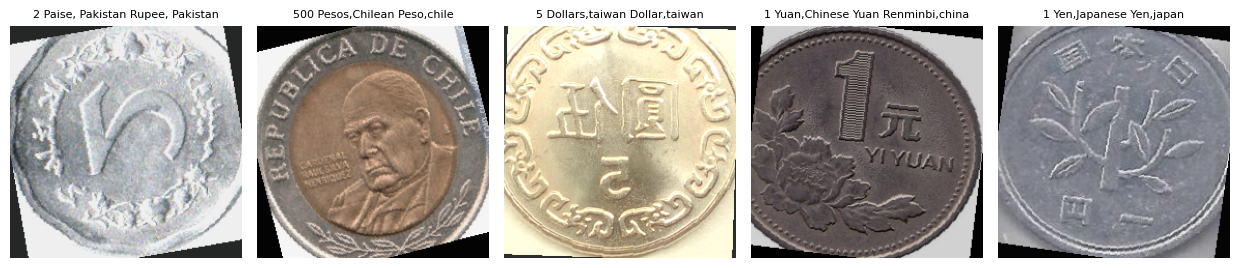

In [17]:
import matplotlib.pyplot as plt
nb_classes= len(full_train.classes)
classes= full_train.classes
def imshow(images, labels, classes, n=5):
    images = images[:n]
    labels = labels[:n]
 
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images_denorm = images * std + mean
    images_denorm = images_denorm.clamp(0, 1)
    
    ncols = min(n, 8)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 3))
    axes = np.array(axes).reshape(-1) 
    for i in range(len(axes)):
        ax = axes[i]
        if i < n:
            npimg = images_denorm[i].numpy().transpose(1, 2, 0)
            ax.imshow(npimg)
            ax.set_title(classes[labels[i].item()], fontsize=8, wrap=True)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def visu(loader, classes):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    imshow(images, labels, classes)

visu(train_loader, classes)




# Model

In [18]:
import torch.nn as nn 
from torchvision import models
from torchvision.models import alexnet, AlexNet_Weights

model = alexnet(weights=AlexNet_Weights.DEFAULT) 
model.classifier = nn.Sequential(
    nn.Dropout(),
    nn.Linear(256 * 6 * 6, 2048),  
    nn.ReLU(inplace=True),
    nn.Dropout(),
    nn.Linear(2048, 1024),           
    nn.ReLU(inplace=True),
    nn.Linear(1024, nb_classes),  
)
model = model.to(device)




# Train

In [19]:


import torch
import torch.nn as nn
import torch.optim as optim
import copy

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
num_epochs = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

train_loss_list, train_acc_list = [], []
val_loss_list, val_acc_list = [], []

best_val_acc = 0.0
best_epoch = -1
best_model_state = None
patience = 5  
epochs_no_improve = 0

for epoch in range(num_epochs):
    #TRAIN
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    #VAL
    model.eval()
    running_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    val_loss = running_loss / len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}/{num_epochs} | LR {current_lr:.6f} | "
          f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_state, "best_model.pth")
        print(f"  -> New best val acc {best_val_acc:.4f}, checkpoint saved.")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"No improvement for {patience} epochs, stopping early "
              f"at epoch {epoch+1}.")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
model.load_state_dict(torch.load("best_model.pth"))


Epoch 1/20 | LR 0.000099 | Train Loss 5.5796 Acc 0.0326 | Val Loss 5.2024 Acc 0.1148
  -> New best val acc 0.1148, checkpoint saved.
Epoch 2/20 | LR 0.000098 | Train Loss 4.7104 Acc 0.1662 | Val Loss 3.7089 Acc 0.3391
  -> New best val acc 0.3391, checkpoint saved.
Epoch 3/20 | LR 0.000095 | Train Loss 3.5131 Acc 0.3753 | Val Loss 2.9014 Acc 0.5258
  -> New best val acc 0.5258, checkpoint saved.
Epoch 4/20 | LR 0.000090 | Train Loss 2.7570 Acc 0.5468 | Val Loss 2.4253 Acc 0.6450
  -> New best val acc 0.6450, checkpoint saved.
Epoch 5/20 | LR 0.000085 | Train Loss 2.3745 Acc 0.6389 | Val Loss 2.2224 Acc 0.6985
  -> New best val acc 0.6985, checkpoint saved.
Epoch 6/20 | LR 0.000079 | Train Loss 2.1259 Acc 0.7044 | Val Loss 2.0876 Acc 0.7221
  -> New best val acc 0.7221, checkpoint saved.
Epoch 7/20 | LR 0.000073 | Train Loss 1.9666 Acc 0.7565 | Val Loss 2.0345 Acc 0.7371
  -> New best val acc 0.7371, checkpoint saved.
Epoch 8/20 | LR 0.000065 | Train Loss 1.8299 Acc 0.7938 | Val Loss 1.

<All keys matched successfully>

# Accuracy/Loss plots

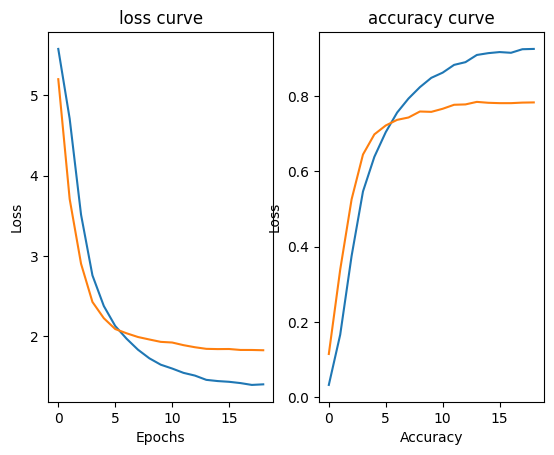

In [20]:
plt.subplot(1,2,1)
plt.plot(range(len(train_loss_list)), train_loss_list)
plt.plot(range(len(val_loss_list)), val_loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("loss curve")

plt.subplot(1,2,2)
plt.plot(range(len(train_acc_list)), train_acc_list)
plt.plot(range(len(val_acc_list)), val_acc_list)

plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.title("accuracy curve")


plt.show()

# Evaluation


In [21]:
model.eval()
test_loss    = 0.0
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        test_loss    += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
    

test_loss = test_loss    / len(test_loader.dataset)
test_acc  = test_correct / len(test_loader.dataset)

print(f"Test Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_acc*100:.6f}%")

Test Loss     : 1.824141
Test Accuracy : 78.581766%
